## Giulia de Sanctis <br>
## Portal Biotech Peptide Challenge Submission <br>


_Task_: The data comes from an analytical chemistry technique called liquid chromatography (LC). Molecules in a mixture are pushed through a column and come out at different times. A molecule's **retention time** is how long it takes, and it depends on the molecule's physical and chemical properties.

The molecules here are **peptides**, short chains of **amino acids** (the building blocks of proteins). There are 20 standard amino acids, each with different properties such as size, charge, and hydrophobicity (how water- or fat-loving it is). A peptide is written as a string of letters, one per amino acid (for example `VALWNEVDGQTK`).

You are given peptide sequences and their measured retention times. It is already known publicly that retention time is largely driven by a peptide's hydrophobicity and size, and predictive models already exist. That is the starting point, not the goal.

In [1]:
# Useful libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1) Load / clean / inspect the dataset

In [2]:
df = pd.read_csv("/Users/giuliadesanctis/Downloads/portal_ds_task/peptide_retention.csv")
df.shape

(10000, 4)

In [3]:
df.head(10)

,ID,PeptideSequence,Modifications,RetentionTime
0,66442,EELNAISGPNEFAEFYDR,NaN,76.808103
1,9346,VPAQSESVR,NaN,-35.365414
2,87137,SEPEDPVTER,NaN,-12.258285
3,31419,SIRPGLSPYR,NaN,-0.953151
4,93265,NLINEMLTINPAK,NaN,88.572770
5,74513,IQPDYPAER,NaN,-4.333334
6,103807,VDREQLVQK,1|Acetyl,4.033374
7,46965,LAQFVEHWK,NaN,24.551452
8,71173,GLFATQLIR,NaN,60.780689
9,80030,VLTANSNPSSPSAAK,NaN,-18.356355


First step is to take a look at the data, see if there are missing values, decide how to deal with them and then check for outliers or strange results. 

In [ ]:
# if there is no modification present, we have a NaN, so let's set the NaN to 0 
df['Modifications'] = df['Modifications'].fillna(0)

print(len(df['Modifications'].unique()))
print(df['Modifications'].value_counts()) # we want to see all the different possible modifications and how often they appear

49
Modifications
0                            9175
1|Acetyl                      151
1|Oxidation                   100
2|Oxidation                    75
4|Oxidation                    54
5|Oxidation                    48
3|Oxidation                    44
10|Oxidation                   34
8|Oxidation                    33
7|Oxidation                    32
9|Oxidation                    30
6|Oxidation                    29
11|Oxidation                   25
14|Oxidation                   24
15|Oxidation                   21
12|Oxidation                   17
13|Oxidation                   16
20|Oxidation                   11
18|Oxidation                   10
16|Oxidation                   10
19|Oxidation                    9
17|Oxidation                    9
21|Oxidation                    5
24|Oxidation                    4
25|Oxidation                    4
23|Oxidation                    3
22|Oxidation                    3
29|Oxidation                    2
30|Oxidation                   

We have 49 different modifications, worth keeping in mind for later to see if there is a useful way of grouping these. 

In [5]:
sum(df.isnull().sum(axis=1))

0

No missing values --> no need for any interpolation. Now let's look at the validity of the values and if there are any outliers / weird values. 

In [6]:
df[df["RetentionTime"] < 0]

,ID,PeptideSequence,Modifications,RetentionTime
1,9346,VPAQSESVR,0,-35.365414
2,87137,SEPEDPVTER,0,-12.258285
3,31419,SIRPGLSPYR,0,-0.953151
5,74513,IQPDYPAER,0,-4.333334
9,80030,VLTANSNPSSPSAAK,0,-18.356355
...,...,...,...,...
9965,2013,MIVQENK,0,-24.980588
9966,46784,GNIMLSQK,0,-4.198438
9972,23293,GSYGSGGSSYGSGGGSYGSGGGGGGHGSYGSGSSSGGYR,0,-8.486796
9980,32318,KEGSDGPLATSKPVPAEK,0,-19.212073


(array([1.000e+00, 1.000e+00, 1.320e+02, 8.390e+02, 1.398e+03, 2.000e+03,
        2.216e+03, 1.750e+03, 1.053e+03, 6.100e+02]),
 array([-131.6075686 , -103.67211654,  -75.73666448,  -47.80121242,
         -19.86576036,    8.0696917 ,   36.00514376,   63.94059582,
          91.87604788,  119.81149994,  147.746952  ]),
 <BarContainer object of 10 artists>)

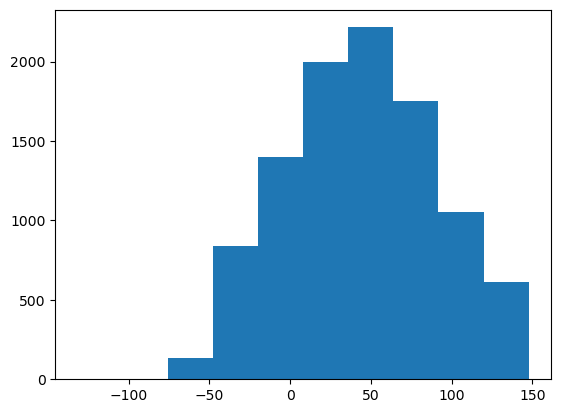

In [7]:
plt.hist(df["RetentionTime"])

We seeem to have a large number (>10%) of negative retention times which initially seems odd as a lapse of time cannot be negative. Is it possible that there is a different unit or that values are standardized? In fact, no unit is explicitly given in the dataset.  <br>
Looking at the distribution of retention times, they seem to be centered at around 50 with a longer tail at positive values rather than negative values but given how many negative values there are, I do not think the negative values are outliers / mistakes. <br>
A possible option is iRT (https://pmc.ncbi.nlm.nih.gov/articles/PMC3918884/) ie a normalized scale calibrated against reference peptides. In this case a negative time would simply mean earlier elution than a reference peptide. So for the purpose of this exercise, I will assume that we are using an iRT scale or similar and leave the values as is. 

Check for duplicates

In [8]:
sum(df.duplicated())

0

Only remaining variable to check is the peptide sequence themselves. My doubts: <br>
1) Can a peptide sequence contain any letter? <br>
2) min and max length for a peptide sequence <br>



From a quick research online: <br>
1) Only 20 letters are valid, one for each standard amino acid: A C D E F G H I K L M N P Q R S T V W Y and the letters B, J, O, U, X, Z are not standard amino acids in typical proteomics data. <br>
2) There's no hard biological limit, but as a general rule:
Minimum: ~6 residues. Anything shorter is usually filtered out because short peptides aren't unique to a single protein and are hard to identify confidently by mass spec.
Maximum: ~30–40 residues, occasionally up to ~50. Longer peptides are harder to ionize, fragment poorly, and often fall outside the m/z range of the instrument.
So most real datasets sit in roughly [7, 30] residues, with a peak around 8–15. 

(array([400., 631., 865., 895., 833., 769., 719., 666., 581., 528., 460.,
        371., 331., 301., 226., 217., 191., 163., 143., 126.,  96.,  76.,
         82.,  66.,  46.,  48.,  39.,  37.,  21.,  22.,  16.,  11.,  14.,
         10.]),
 array([ 7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19.,
        20., 21., 22., 23., 24., 25., 26., 27., 28., 29., 30., 31., 32.,
        33., 34., 35., 36., 37., 38., 39., 40., 41.]),
 <BarContainer object of 34 artists>)

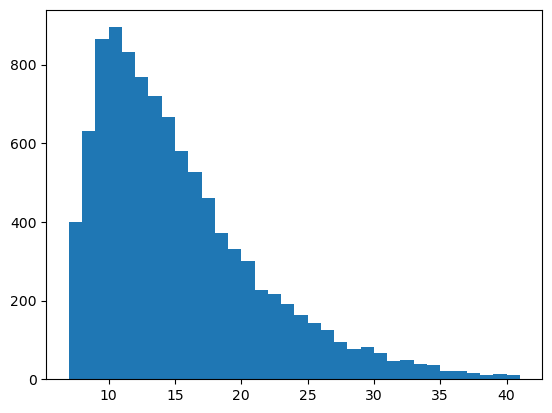

In [9]:
# Let's check our data
valid = set("ACDEFGHIKLMNPQRSTVWY")
bad = df[~df['PeptideSequence'].apply(lambda s: set(s).issubset(valid))]
bad

plt.hist(df['PeptideSequence'].str.len(), bins=range(df['PeptideSequence'].str.len().min(), df['PeptideSequence'].str.len().max()+2))

Peak seems to be at aroudn 11/12 which seems consistent with what I found online. There is a tail that goes all the way to 41/42 but those seem to be just a few cases so everything seems to be ok. 

### Conclusion so far: The dataset seems to already be cleaned and ready for analytical use. The only change I made was to change the NaNs in modifications to a zero if there hadn't been any modification. The next step is to perform feature selection / engineering to get the data ready to test out a few different regression models. The README with challenge instructions states that there is a well-known relationship between retention time and peptide's hydrophobicity and size, so this is a good place to start

# 2) Feature selection and engineering for modelling


Questions: <br>
1) We are told that peptide size and hydrophobicity influence retention time. In what way? Worth looking into this briefly so I have an idea of if my models are behaving well or not. <br>
2) Can we tell a peptide's size from its sequence? <br>
3) Can we tell a peptide's hydrophobicity from its sequence? <br>

A quick internet search confirms that: <br>
1) Hydrophobicity is the dominant driver. Peptides rich in hydrophobic residues (L, I, V, F, W, M, Y, A) bind the column tightly and elute late (high RT). Peptides rich in polar/charged residues (K, R, D, E, N, Q, S, T, H) barely bind and elute early (low RT). Size matters as a secondary effect: a longer peptide has more residues contacting the column surface, so given the same average hydrophobicity, longer peptides elute later. In practice, size and hydrophobicity are correlated: total hydrophobicity (sum, not mean) scales with length, and this is what most predictors actually use.
2) Since peptides are chains of amino acids, their length directly correlates to their molecular weight and physical mass. Longer chain --> bigger peptide. <br>
3) There are hydrophobicity scale and lookup tables giving each amino acid a numeric hydrophobicity value. Kyte–Doolittle (1982) is a common one. Range roughly −4.5 (R, most hydrophilic) to +4.5 (I, most hydrophobic).

KD = {
    'A':  1.8, 'C':  2.5, 'D': -3.5, 'E': -3.5, 'F':  2.8,
    'G': -0.4, 'H': -3.2, 'I':  4.5, 'K': -3.9, 'L':  3.8,
    'M':  1.9, 'N': -3.5, 'P': -1.6, 'Q': -3.5, 'R': -4.5,
    'S': -0.8, 'T': -0.7, 'V':  4.2, 'W': -0.9, 'Y': -1.3,
}

In [10]:
# It would thereofre seem sensible to add 3 new columns to the dataset, one that captures the length of the peptide length, one that 
# captures the sum of the hydrophobicity,.

# Peptide length
df["peptide_length"] = df["PeptideSequence"].str.len()

# Hydrophobicity calculated usign KD values
KD = {
    'A':  1.8, 'C':  2.5, 'D': -3.5, 'E': -3.5, 'F':  2.8,
    'G': -0.4, 'H': -3.2, 'I':  4.5, 'K': -3.9, 'L':  3.8,
    'M':  1.9, 'N': -3.5, 'P': -1.6, 'Q': -3.5, 'R': -4.5,
    'S': -0.8, 'T': -0.7, 'V':  4.2, 'W': -0.9, 'Y': -1.3,
}

def sum_kd(sequence):
    return sum(KD[aa] for aa in sequence)

df['sum_kd'] = df['PeptideSequence'].apply(sum_kd)

df.head(10)

,ID,PeptideSequence,Modifications,RetentionTime,peptide_length,sum_kd
0,66442,EELNAISGPNEFAEFYDR,0,76.808103,18,-15.6
1,9346,VPAQSESVR,0,-35.365414,9,-4.5
2,87137,SEPEDPVTER,0,-12.258285,10,-19.0
3,31419,SIRPGLSPYR,0,-0.953151,10,-7.2
4,93265,NLINEMLTINPAK,0,88.572770,13,0.1
5,74513,IQPDYPAER,0,-4.333334,9,-13.2
6,103807,VDREQLVQK,1|Acetyl,4.033374,9,-10.2
7,46965,LAQFVEHWK,0,24.551452,9,-2.4
8,71173,GLFATQLIR,0,60.780689,9,7.6
9,80030,VLTANSNPSSPSAAK,0,-18.356355,15,-4.6


Now all that remains to be dealt with are the values of modifications. Looking at the modifications we have, it seems to me that we have four different kinds: 
1) No modification
2) Acetyl 
3) Oxidation
4) Oxidation - Oxidation

So I think I can add two more variables: a binary variable that shows if acetyl has been added and another variable that represents if 0,1 or 2 oxidations have been performed. 

In [11]:
def parse_mods(s):
    if s == 0 or pd.isna(s):
        return 0, 0
    parts = str(s).split('|')
    mods = parts[1::2]  
    has_acetyl = int('Acetyl' in mods)
    n_oxidations = mods.count('Oxidation')
    return has_acetyl, n_oxidations

df[['has_acetyl', 'n_oxidations']] = df['Modifications'].apply(
    lambda s: pd.Series(parse_mods(s))
)

In [12]:
len(df["ID"].unique())

10000

In [13]:
df.head(10)

,ID,PeptideSequence,Modifications,RetentionTime,peptide_length,sum_kd,has_acetyl,n_oxidations
0,66442,EELNAISGPNEFAEFYDR,0,76.808103,18,-15.6,0,0
1,9346,VPAQSESVR,0,-35.365414,9,-4.5,0,0
2,87137,SEPEDPVTER,0,-12.258285,10,-19.0,0,0
3,31419,SIRPGLSPYR,0,-0.953151,10,-7.2,0,0
4,93265,NLINEMLTINPAK,0,88.572770,13,0.1,0,0
5,74513,IQPDYPAER,0,-4.333334,9,-13.2,0,0
6,103807,VDREQLVQK,1|Acetyl,4.033374,9,-10.2,1,0
7,46965,LAQFVEHWK,0,24.551452,9,-2.4,0,0
8,71173,GLFATQLIR,0,60.780689,9,7.6,0,0
9,80030,VLTANSNPSSPSAAK,0,-18.356355,15,-4.6,0,0


We can now drop ID and modifications from the table. "ID" because it doesn't give us any information about retention time (I assume it is simply an identifier for each experiment, and in fact we have 1000 unique values) and "Modifications" because we have codified the information it carries with the two variables "has_acetyl" and "n_oxidations". I leave peptide sequence for now because I need to keep it for doing the train-test split. Since there are some peptide sequences that appear more than once, we cannot haev the same sequence appear in both train and test --> data leakage! So we need to split accordingly. 

In [14]:
df = df[["PeptideSequence", "RetentionTime", "peptide_length", "sum_kd", "has_acetyl", "n_oxidations"]]
df.head()

,PeptideSequence,RetentionTime,peptide_length,sum_kd,has_acetyl,n_oxidations
0,EELNAISGPNEFAEFYDR,76.808103,18,-15.6,0,0
1,VPAQSESVR,-35.365414,9,-4.5,0,0
2,SEPEDPVTER,-12.258285,10,-19.0,0,0
3,SIRPGLSPYR,-0.953151,10,-7.2,0,0
4,NLINEMLTINPAK,88.572770,13,0.1,0,0


In [15]:
from sklearn.model_selection import train_test_split

peptides = df["PeptideSequence"].unique()

train_peptides, test_peptides = train_test_split(
    peptides,
    test_size=0.2,
    random_state=42
)

df_train = df[df["PeptideSequence"].isin(train_peptides)]
df_test = df[df["PeptideSequence"].isin(test_peptides)]

# Verify no overlap
overlap = set(df_train["PeptideSequence"]) & set(df_test["PeptideSequence"])

In [16]:
X_train = df_train[["peptide_length", "sum_kd", "has_acetyl", "n_oxidations"]]
X_test = df_test[["peptide_length", "sum_kd", "has_acetyl", "n_oxidations"]]
y_train = df_train[["RetentionTime"]]
y_test = df_test[["RetentionTime"]]

In [ ]:
#X_train_enc = pd.get_dummies(X_train, columns=["n_oxidations"])
#X_test_enc = pd.get_dummies(X_test, columns=["n_oxidations"])

In [17]:
X_train.head(), X_test.head(), y_train.head(), y_test.head()

(   peptide_length  sum_kd  has_acetyl  n_oxidations
 1               9    -4.5           0             0
 2              10   -19.0           0             0
 4              13     0.1           0             0
 5               9   -13.2           0             0
 6               9   -10.2           1             0,
     peptide_length  sum_kd  has_acetyl  n_oxidations
 0               18   -15.6           0             0
 3               10    -7.2           0             0
 8                9     7.6           0             0
 10              13   -13.7           0             0
 12              11   -14.8           0             0,
    RetentionTime
 1     -35.365414
 2     -12.258285
 4      88.572770
 5      -4.333334
 6       4.033374,
     RetentionTime
 0       76.808103
 3       -0.953151
 8       60.780689
 10      26.270934
 12       1.006815)

# 3) Base model: linear regression

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


reg = LinearRegression().fit(X_train, y_train)
print("Train R²:", reg.score(X_train, y_train))
print("Test R²:", reg.score(X_test, y_test))

# Predict from X_test, not y_test
y_pred = reg.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f}")

residuals = np.abs(y_test - y_pred)
delta_t95 = np.percentile(residuals, 95)
print(f"Δt95: {delta_t95:.2f}")


Train R²: 0.5180750474751531
Test R²: 0.5071210587956471
MAE: 25.97
Δt95: 62.02


R squared seems to be very low, maybe we have compressed ifnormation too much by only including sum of KD values. Might makes sense to add frequency information eg how many letters of the chain are A, how many are C etc as a way to restore some info about the peptide chain. 

In [19]:
from collections import Counter

AAs = list('ACDEFGHIKLMNPQRSTVWY')

def aa_composition(sequences):
    comp = sequences.apply(lambda s: pd.Series(Counter(s)))
    comp = comp.reindex(columns=AAs, fill_value=0).fillna(0)
    comp.index = sequences.index  
    return comp

train_comp = aa_composition(df_train['PeptideSequence'])
test_comp  = aa_composition(df_test['PeptideSequence'])

X_train = pd.concat([df_train.drop(columns=['PeptideSequence', 'RetentionTime']), train_comp], axis=1)
X_test  = pd.concat([df_test.drop(columns=['PeptideSequence', 'RetentionTime']),  test_comp],  axis=1)

In [20]:
X_train.head()

,peptide_length,sum_kd,has_acetyl,n_oxidations,A,C,D,E,F,G,...,M,N,P,Q,R,S,T,V,W,Y
1,9,-4.5,0,0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,2.0,0.0,2.0,0.0,0.0
2,10,-19.0,0,0,0.0,0.0,1.0,3.0,0.0,0.0,...,0.0,0.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0
4,13,0.1,0,0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,3.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5,9,-13.2,0,0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
6,9,-10.2,1,0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,2.0,1.0,0.0,0.0,2.0,0.0,0.0


Now we try and run the exact same model as before and see if there are improvements. 

In [21]:
reg = LinearRegression().fit(X_train, y_train)
print("Train R²:", reg.score(X_train, y_train))
print("Test R²:", reg.score(X_test, y_test))

# Predict from X_test, not y_test
y_pred = reg.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f} ")

residuals = np.abs(y_test - y_pred)
delta_t95 = 2 * np.percentile(residuals, 95)
print(f"Δt95: {delta_t95:.2f} ")

Train R²: 0.8623403842204198
Test R²: 0.85796573992147
MAE: 12.85 
Δt95: 66.62 


We see a marked improvement --> so it is probably correct that previosuly we had condensed the information too much and the model didn't have enough data to form a complete picture. This is not a bad point to start from, we can try a few other approaches like lasso / ridge regression or decision trees. 
Potential pitfalls: 
- lasso & ridge are worth a shot because the linear model performs well. However, there doesn't seem to be a huge problem with overfitting (R^2 on train and test is very similar, so lasso in particular probably won't help much as it often reduces overfitting)

# 4) Lasso & Ridge Regression

In [22]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

ridge = Ridge(alpha=1.0).fit(X_train_s, y_train)
lasso = Lasso(alpha=0.1).fit(X_train_s, y_train)

# Ridge
print(f"Ridge Train R²: {ridge.score(X_train_s, y_train):.4f}")
print(f"Ridge Test R²: {ridge.score(X_test_s, y_test):.4f}")
y_pred_ridge = ridge.predict(X_test_s)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
print(f"Ridge MAE: {mae_ridge:.2f} ")
residuals = np.abs(y_test.squeeze().values - y_pred_ridge)
delta_t95 = np.percentile(residuals, 95)
print(f"Ridge Δt95: {delta_t95:.2f}  \n")

# Lasso
print(f"Lasso Train R²: {lasso.score(X_train_s, y_train):.4f}")
print(f"Lasso Test R²: {lasso.score(X_test_s, y_test):.4f}")
y_pred_lasso = lasso.predict(X_test_s)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
print(f"Lasso MAE: {mae_lasso:.2f} ")
residuals = np.abs(y_test.squeeze().values - y_pred_lasso)  # was y_pred_ridge — bug
delta_t95 = 2 * np.percentile(residuals, 95)
print(f"Lasso Δt95: {delta_t95:.2f} ")

Ridge Train R²: 0.8623
Ridge Test R²: 0.8580
Ridge MAE: 12.85 
Ridge Δt95: 33.31  

Lasso Train R²: 0.8622
Lasso Test R²: 0.8576
Lasso MAE: 12.88 
Lasso Δt95: 66.64 


I standardzed to avoid ridge and lasso penalizing the magnitude of coefficients, but as expected there doesn't seem to be any improvement in using lasso/ridge. They work just as well as a normal linear regression. With more time, I could try and maybe perform a grid search on the value of alpha, but I don't expect there to be a huge difference regardless.

# 5) Decision trees

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=100,          
    min_samples_leaf=5,    
    min_samples_split=10,  
    max_features='sqrt',   
    random_state=42,
    n_jobs=-1
).fit(X_train, y_train)

print(f"Train R²: {rf.score(X_train, y_train):.4f}")
print(f"Test R²:  {rf.score(X_test, y_test):.4f}")

y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f} ")

residuals = np.abs(y_test.squeeze().values - y_pred)
delta_t95 = 2 * np.percentile(residuals, 95)
print(f"Δt95: {delta_t95:.2f} ")

/Users/giuliadesanctis/miniconda3/envs/study/lib/python3.14/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Train R²: 0.8635
Test R²:  0.7866
MAE: 16.74 
Δt95: 85.67 


Again, linear regression seems to be the best model and outperforms the decision trees. This is not entriely unexpected as decision trees have a tendency to overfit and the README mentions that there is a known relationship between molecule size and hydrophobicity and retention time. It is not difficult to imagine that this relationship is linear or close to, so the linear model works well and captures the pattern well, whilst the decision trees which fare well when there are complex patterns to be identified, overfits and performs more poorly. Again, with more time, I would perform more parameter tuning that could be done through a grid search and cross-validation to choose all the parameters set in "RandomForestRegressor" and these could potentially lead to improvements in the performance, but overall it seems that the linear model is the best choice. 

## Quick note on the metrics chosen: 
After quick research, it seems that 2 common metrics used in RT-prediction literature are the MAE and delta-t-95. We include them because: <br>
R/R²: overall goodness of fit <br>
MAE: typical error, size directly interpretable and robust to outliers compared to RMSE. <br>
delta-t-95: twice the 0.95 quantile of the absolute RT error. This was a metric I had not used before, but is apparently field-specific and so worth including. <br>